# 05 — Mining Analysis (Risk-Aware)

Analyzes weekly topic activity, detects anomalies, and produces simple short-horizon forecasts.

Inputs:
- `data/timeseries.csv`
- `data/timeseries_wide.csv`

Outputs:
- `data/forecasts.csv`
- `data/anomalies.csv`
- `data/anomaly_detection.png`

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

ts = pd.read_csv('data/timeseries.csv', parse_dates=['week'])
ts = ts.sort_values(['primary_topic', 'week']).reset_index(drop=True)

required_cols = [
    'week', 'primary_topic', 'article_count', 'sentiment_mean',
    'risk_score_mean', 'risk_index_mean', 'high_risk_share'
]
missing = [c for c in required_cols if c not in ts.columns]
if missing:
    raise ValueError(f'Missing core columns in data/timeseries.csv: {missing}. Re-run notebook 04.')

# Backward-compatible defaults for optional engineered columns
optional_defaults = {
    'negative_ratio': 0.0,
    'article_count_roll4_mean': np.nan,
    'risk_index_roll4_mean': np.nan,
}
for col, default in optional_defaults.items():
    if col not in ts.columns:
        ts[col] = default

# Recompute rolling baselines if absent/empty
if ts['article_count_roll4_mean'].isna().all():
    ts['article_count_roll4_mean'] = (
        ts.groupby('primary_topic')['article_count']
          .transform(lambda s: s.rolling(4, min_periods=1).mean())
    )
if ts['risk_index_roll4_mean'].isna().all():
    ts['risk_index_roll4_mean'] = (
        ts.groupby('primary_topic')['risk_index_mean']
          .transform(lambda s: s.rolling(4, min_periods=1).mean())
    )

ts['negative_ratio'] = pd.to_numeric(ts['negative_ratio'], errors='coerce').fillna(0.0)
ts['article_count_roll4_mean'] = pd.to_numeric(ts['article_count_roll4_mean'], errors='coerce').fillna(0.0)
ts['risk_index_roll4_mean'] = pd.to_numeric(ts['risk_index_roll4_mean'], errors='coerce').fillna(0.0)

print(ts.shape)
print(ts.columns.tolist())
ts.head()

(1299, 16)
['week', 'primary_topic', 'article_count', 'sentiment_mean', 'sentiment_std', 'positive_ratio', 'negative_ratio', 'risk_score_mean', 'risk_score_max', 'risk_index_mean', 'high_risk_share', 'article_count_lag1', 'article_count_lag4', 'article_count_pct_change_1w', 'article_count_roll4_mean', 'risk_index_roll4_mean']


,week,primary_topic,article_count,sentiment_mean,sentiment_std,positive_ratio,negative_ratio,risk_score_mean,risk_score_max,risk_index_mean,high_risk_share,article_count_lag1,article_count_lag4,article_count_pct_change_1w,article_count_roll4_mean,risk_index_roll4_mean
0,2022-07-18,ai,3,-0.9246,0.000000,0.0,1.0,0.0,0,0.27740,0.0,NaN,NaN,NaN,3.000000,0.277400
1,2022-07-25,ai,2,0.6115,0.000000,1.0,0.0,0.0,0,0.18340,0.0,3.0,NaN,-0.333333,2.500000,0.230400
2,2022-09-19,ai,6,-0.6044,0.035602,0.0,1.0,0.0,0,0.18135,0.0,2.0,NaN,2.000000,3.666667,0.214050
3,2022-09-26,ai,3,-0.7845,0.000000,0.0,1.0,0.0,0,0.23530,0.0,6.0,NaN,-0.500000,3.500000,0.219362
4,2022-10-03,ai,3,-0.7845,0.000000,0.0,1.0,0.0,0,0.23530,0.0,3.0,3.0,0.000000,3.500000,0.208838


## Topic-Level Trend Snapshot

In [20]:
summary = (
    ts.groupby('primary_topic', as_index=False)
      .agg(
          weeks=('week', 'nunique'),
          total_articles=('article_count', 'sum'),
          avg_articles=('article_count', 'mean'),
          avg_sentiment=('sentiment_mean', 'mean'),
          avg_risk=('risk_index_mean', 'mean'),
          peak_risk=('risk_index_mean', 'max'),
      )
      .sort_values(['avg_risk', 'total_articles'], ascending=[False, False])
)

print('Topic risk/activity summary:')
print(summary.to_string(index=False))

Topic risk/activity summary:
       primary_topic  weeks  total_articles  avg_articles  avg_sentiment  avg_risk  peak_risk
    defense_security      5              14      2.800000       0.195940  0.201140     0.2353
     finance_banking      2               4      2.000000      -0.653100  0.195900     0.2597
 food_water_security      4              12      3.000000      -0.241075  0.193425     0.2673
   technology_policy      1               3      3.000000      -0.624900  0.187500     0.1875
geopolitics_conflict    216           73357    339.615741      -0.223886  0.170449     0.2830
                  ai    185            9694     52.400000       0.002390  0.162428     0.2774
        macroeconomy    189            3811     20.164021       0.037215  0.157664     0.2838
elections_governance    109            1084      9.944954      -0.023007  0.156660     0.2687
       public_health    155            9089     58.638710      -0.153323  0.154815     0.2845
      energy_markets    175    

## Anomaly Detection (Volume + Risk)

Uses Isolation Forest per topic on weekly features to flag unusual weeks.

In [21]:
feature_cols = [
    'article_count', 'sentiment_mean', 'negative_ratio',
    'risk_score_mean', 'risk_index_mean', 'high_risk_share'
]
feature_cols = [c for c in feature_cols if c in ts.columns]

all_anoms = []
for topic, grp in ts.groupby('primary_topic'):
    g = grp.sort_values('week').copy()
    if len(g) < 12:
        continue

    X = g[feature_cols].copy().fillna(0)
    contamination = min(0.12, max(0.03, 3 / len(g)))

    clf = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42,
    )
    preds = clf.fit_predict(X)
    scores = clf.decision_function(X)

    g['is_anomaly'] = (preds == -1).astype(int)
    g['anomaly_score'] = -scores
    g['anomaly_reason'] = np.where(
        (g['article_count'] > g['article_count_roll4_mean'] * 1.5) &
        (g['risk_index_mean'] > g['risk_index_roll4_mean'] * 1.2),
        'volume_and_risk_spike',
        np.where(
            g['article_count'] > g['article_count_roll4_mean'] * 1.5,
            'volume_spike',
            np.where(
                g['risk_index_mean'] > g['risk_index_roll4_mean'] * 1.2,
                'risk_spike',
                'distribution_shift'
            )
        )
    )
    all_anoms.append(g)

anoms = pd.concat(all_anoms, ignore_index=True) if all_anoms else pd.DataFrame()
anoms_out = anoms[anoms['is_anomaly'] == 1].copy()
anoms_out = anoms_out.sort_values(['anomaly_score', 'week'], ascending=[False, False])

anoms_out.to_csv('data/anomalies.csv', index=False)
print(f'Saved: data/anomalies.csv ({len(anoms_out):,} anomaly rows)')

anoms_out[['week', 'primary_topic', 'article_count', 'risk_index_mean', 'anomaly_score', 'anomaly_reason']].head(20)

Saved: data/anomalies.csv (44 anomaly rows)


,week,primary_topic,article_count,risk_index_mean,anomaly_score,anomaly_reason
632,2021-10-25,geopolitics_conflict,3,0.023200,0.127857,distribution_shift
1062,2023-10-23,public_health,4,0.242750,0.101369,risk_spike
634,2022-01-31,geopolitics_conflict,3,0.167200,0.092501,distribution_shift
635,2022-02-21,geopolitics_conflict,3,0.283000,0.077057,risk_spike
197,2023-04-03,climate_weather,3,0.246800,0.076598,risk_spike
8,2022-11-07,ai,1,0.030800,0.071337,distribution_shift
666,2022-10-24,geopolitics_conflict,3,0.038400,0.068158,distribution_shift
468,2022-11-14,energy_markets,6,0.261100,0.059181,volume_spike
637,2022-03-07,geopolitics_conflict,6,0.055500,0.052672,distribution_shift
1215,2025-11-03,supply_chain,12,0.165625,0.048695,volume_spike


## Quick Visualization

Saved: data/anomaly_detection.png


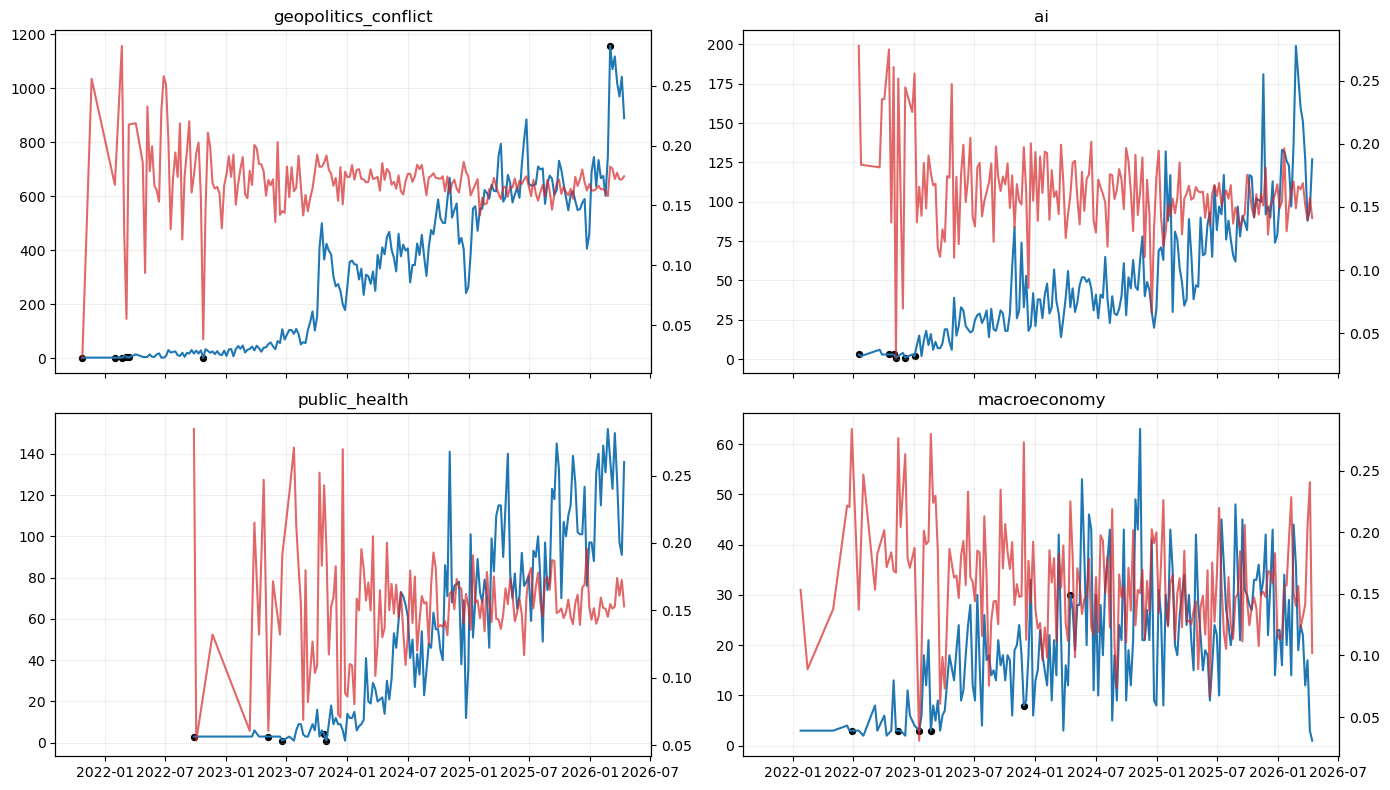

In [22]:
top_topics = (
    ts.groupby('primary_topic')['article_count']
      .sum()
      .sort_values(ascending=False)
      .head(4)
      .index
      .tolist()
)

if len(top_topics) == 0:
    raise ValueError('No topics available to plot. Check data/timeseries.csv content.')

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, topic in enumerate(top_topics[:4]):
    g = ts[ts['primary_topic'] == topic].sort_values('week')
    a = anoms_out[anoms_out['primary_topic'] == topic]

    ax = axes[i]
    ax.plot(g['week'], g['article_count'], label='article_count', color='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(g['week'], g['risk_index_mean'], label='risk_index_mean', color='tab:red', alpha=0.7)

    if not a.empty:
        ax.scatter(a['week'], a['article_count'], color='black', s=18, label='anomaly')

    ax.set_title(topic)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('data/anomaly_detection.png', dpi=180)
print('Saved: data/anomaly_detection.png')

## Baseline Forecasts (next 8 weeks)

Simple robust baseline using recent level + linear drift from last 8 points.

In [23]:
def baseline_forecast(series: pd.Series, horizon: int = 8) -> np.ndarray:
    y = series.astype(float).values
    if len(y) == 0:
        return np.zeros(horizon)
    if len(y) < 3:
        return np.repeat(max(y[-1], 0), horizon)

    window = y[-8:] if len(y) >= 8 else y
    level = np.nanmean(window)
    drift = (window[-1] - window[0]) / max(len(window) - 1, 1)

    out = np.array([level + drift * (i + 1) for i in range(horizon)])
    return np.clip(out, 0, None)


horizon = 8
forecast_rows = []

for topic, grp in ts.groupby('primary_topic'):
    g = grp.sort_values('week')
    if len(g) < 8:
        continue

    last_week = g['week'].max()
    future_weeks = pd.date_range(last_week + pd.Timedelta(days=7), periods=horizon, freq='W-MON')

    fc_count = baseline_forecast(g['article_count'], horizon=horizon)
    fc_risk = baseline_forecast(g['risk_index_mean'], horizon=horizon)

    for w, y1, y2 in zip(future_weeks, fc_count, fc_risk):
        forecast_rows.append({
            'week': w,
            'primary_topic': topic,
            'forecast_article_count': float(y1),
            'forecast_risk_index_mean': float(y2),
        })

forecasts = pd.DataFrame(forecast_rows).sort_values(['primary_topic', 'week'])
forecasts.to_csv('data/forecasts.csv', index=False)
print(f'Saved: data/forecasts.csv ({len(forecasts):,} rows)')

forecasts.head(20)

Saved: data/forecasts.csv (80 rows)


,week,primary_topic,forecast_article_count,forecast_risk_index_mean
0,2026-04-20,ai,130.589286,0.153621
1,2026-04-27,ai,120.303571,0.152508
2,2026-05-04,ai,110.017857,0.151396
3,2026-05-11,ai,99.732143,0.150283
4,2026-05-18,ai,89.446429,0.149170
5,2026-05-25,ai,79.160714,0.148058
6,2026-06-01,ai,68.875000,0.146945
7,2026-06-08,ai,58.589286,0.145833
8,2026-04-20,climate_weather,20.142857,0.157382
9,2026-04-27,climate_weather,21.285714,0.157736


# 05 — Time Series Mining
Trend analysis, anomaly detection, and cross-correlation between subtopics.
Input: `data/timeseries.csv`

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ts = pd.read_csv('data/timeseries.csv', parse_dates=['week'])
if 'subtopic' not in ts.columns and 'primary_topic' in ts.columns:
    ts['subtopic'] = ts['primary_topic']
subtopics = ts['subtopic'].unique().tolist()
for k,v in enumerate(subtopics): print(f"{k}: {v}")

0: ai
1: climate_weather
2: commodities_metals
3: cybersecurity
4: defense_security
5: elections_governance
6: energy_markets
7: finance_banking
8: food_water_security
9: geopolitics_conflict
10: labor_social
11: macroeconomy
12: natural_disasters
13: public_health
14: supply_chain
15: technology_policy
16: trade_industry


## 1. Trend Analysis — Moving Average per Subtopic

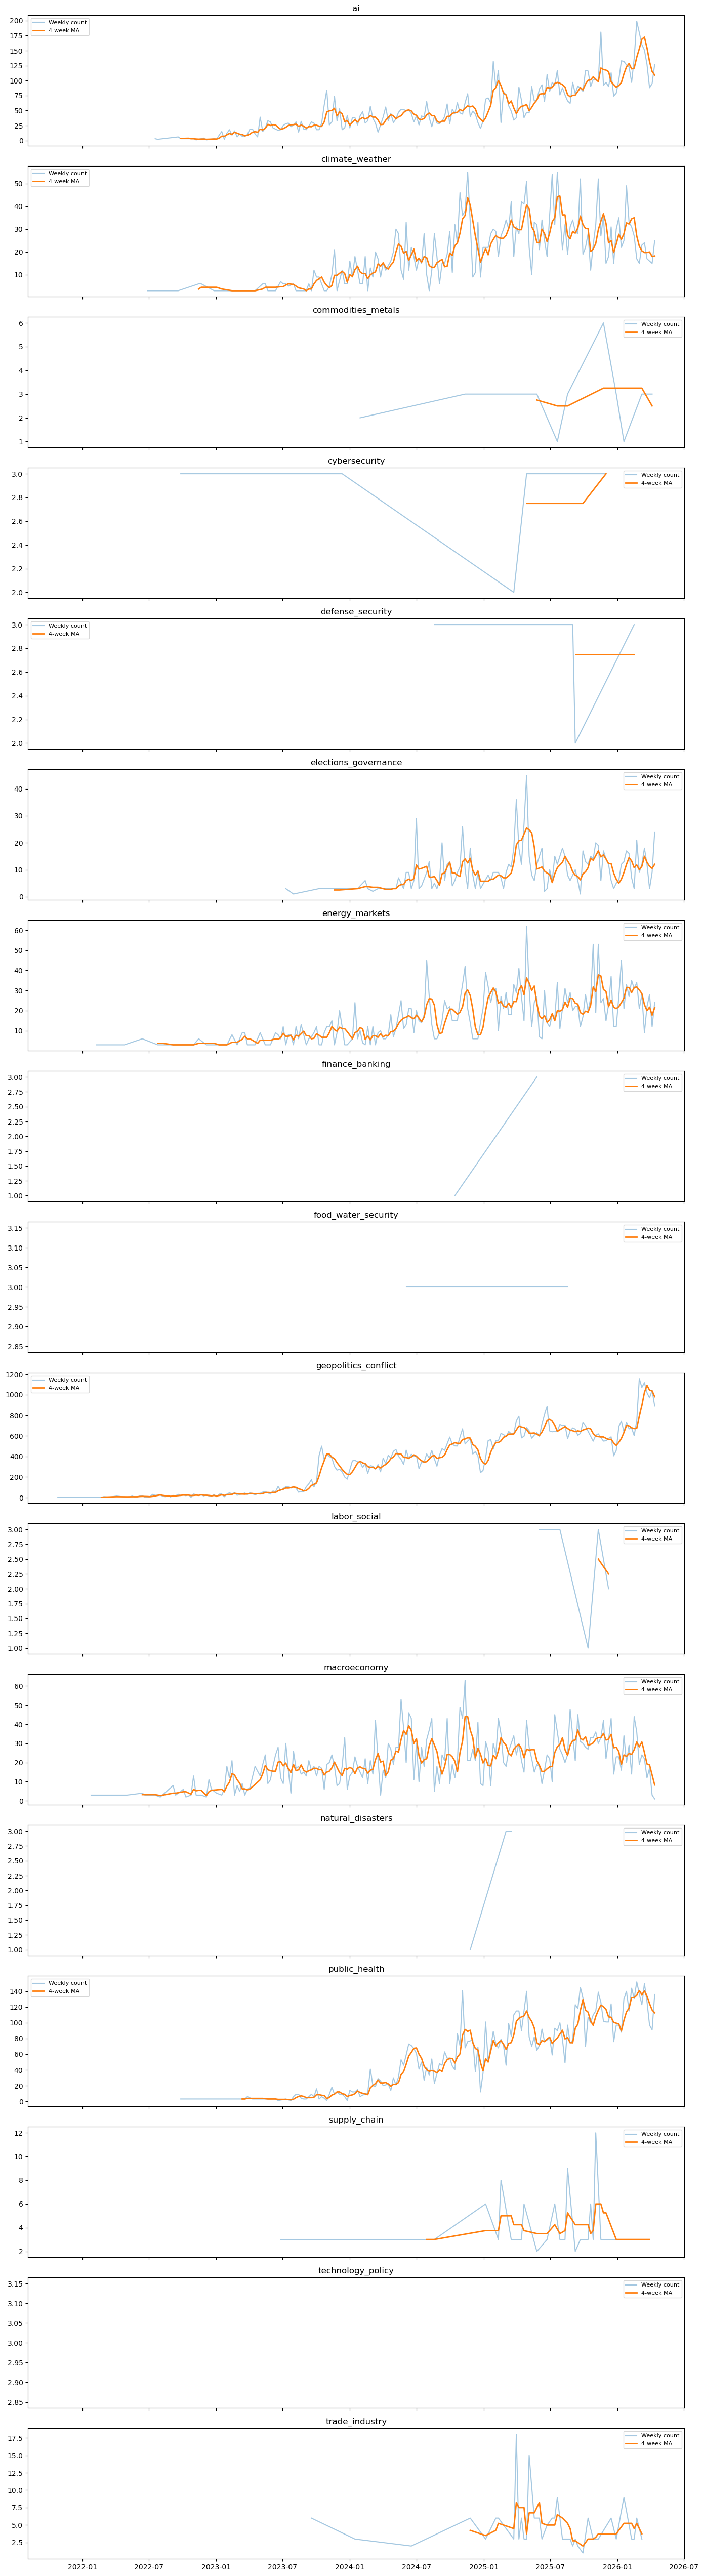

In [25]:
fig, axes = plt.subplots(len(subtopics), 1, figsize=(14, 3 * len(subtopics)), sharex=True)

for ax, topic in zip(axes, subtopics):
    sub = ts[ts['subtopic'] == topic].set_index('week').sort_index()
    ax.plot(sub.index, sub['article_count'], alpha=0.4, label='Weekly count')
    ax.plot(sub.index, sub['article_count'].rolling(4).mean(), linewidth=2, label='4-week MA')
    ax.set_title(topic)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('data/trend_analysis.png', dpi=150)
plt.show()

## 2. Anomaly Detection — Z-score per Subtopic
Flag weeks where article_count is > 2 std deviations from the mean.

In [26]:
from scipy import stats

anomaly_records = []

for topic in subtopics:
    sub = ts[ts['subtopic'] == topic].copy().sort_values('week')
    sub['z_score'] = stats.zscore(sub['article_count'].fillna(0))
    anomalies = sub[sub['z_score'].abs() > 2]
    anomaly_records.append(anomalies.assign(subtopic=topic))

anomaly_df = pd.concat(anomaly_records)
print(f'{len(anomaly_df)} anomalous weeks detected')
anomaly_df[['week', 'subtopic', 'article_count', 'z_score']].sort_values('z_score', ascending=False).head(20)

46 anomalous weeks detected


/var/folders/5b/db0fjbrj0ndd77wcj0wd2dfc0000gn/T/ipykernel_23802/1480227886.py:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sub['z_score'] = stats.zscore(sub['article_count'].fillna(0))


,week,subtopic,article_count,z_score
431,2025-04-28,elections_governance,45,4.701531
1267,2025-03-31,trade_industry,18,4.010673
604,2025-04-28,energy_markets,62,3.939853
177,2026-02-23,ai,199,3.652703
1252,2025-11-03,supply_chain,12,3.514553
427,2025-03-31,elections_governance,36,3.494464
996,2024-11-11,macroeconomy,63,3.449102
163,2025-11-17,ai,181,3.204213
178,2026-03-02,ai,180,3.179296
632,2025-11-10,energy_markets,53,3.171493


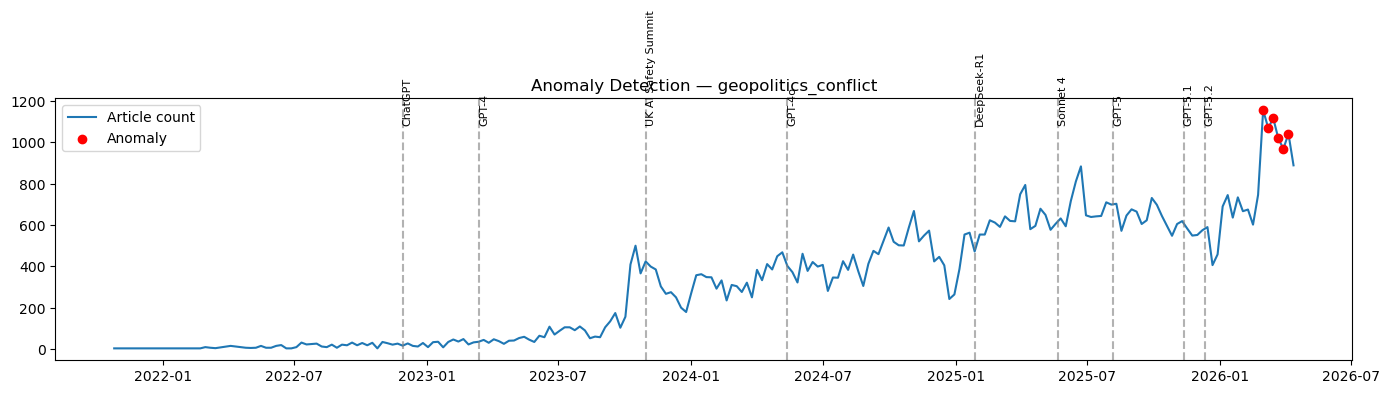

In [ ]:
# Plot anomalies for one subtopic as example
# Set TOPIC to any subtopic name discovered in NB 02 (printed above in `subtopics` list)
TOPIC = subtopics[9]   # default: largest topic; change as needed after reviewing subtopics
sub = ts[ts['subtopic'] == TOPIC].copy().sort_values('week')
sub['z_score'] = stats.zscore(sub['article_count'].fillna(0))
anom = sub[sub['z_score'].abs() > 2]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sub['week'], sub['article_count'], label='Article count')
ax.scatter(anom['week'], anom['article_count'], color='red', zorder=5, label='Anomaly')

# Annotate known events — add/remove as appropriate for your discovered topics
EVENTS = {
    '2022-11-28': 'ChatGPT',
    '2023-03-14': 'GPT-4',
    '2023-10-30': 'UK AI Safety Summit',
    '2024-05-13': 'GPT-4o',
    '2025-01-27': 'DeepSeek-R1',
    '2025-05-22': 'Sonnet 4',
    '2025-08-07': 'GPT-5',
    '2025-11-12': 'GPT-5.1',
    '2025-12-11': 'GPT-5.2'
}
for date_str, label in EVENTS.items():
    ax.axvline(pd.to_datetime(date_str), color='gray', linestyle='--', alpha=0.6)
    ax.text(pd.to_datetime(date_str), ax.get_ylim()[1] * 0.9, label, rotation=90, fontsize=8)

ax.set_title(f'Anomaly Detection — {TOPIC}')
ax.legend()
plt.tight_layout()
plt.savefig('data/anomaly_detection.png', dpi=150)
plt.show()


## 3. Stacked Area Chart — Subtopic Share over Time

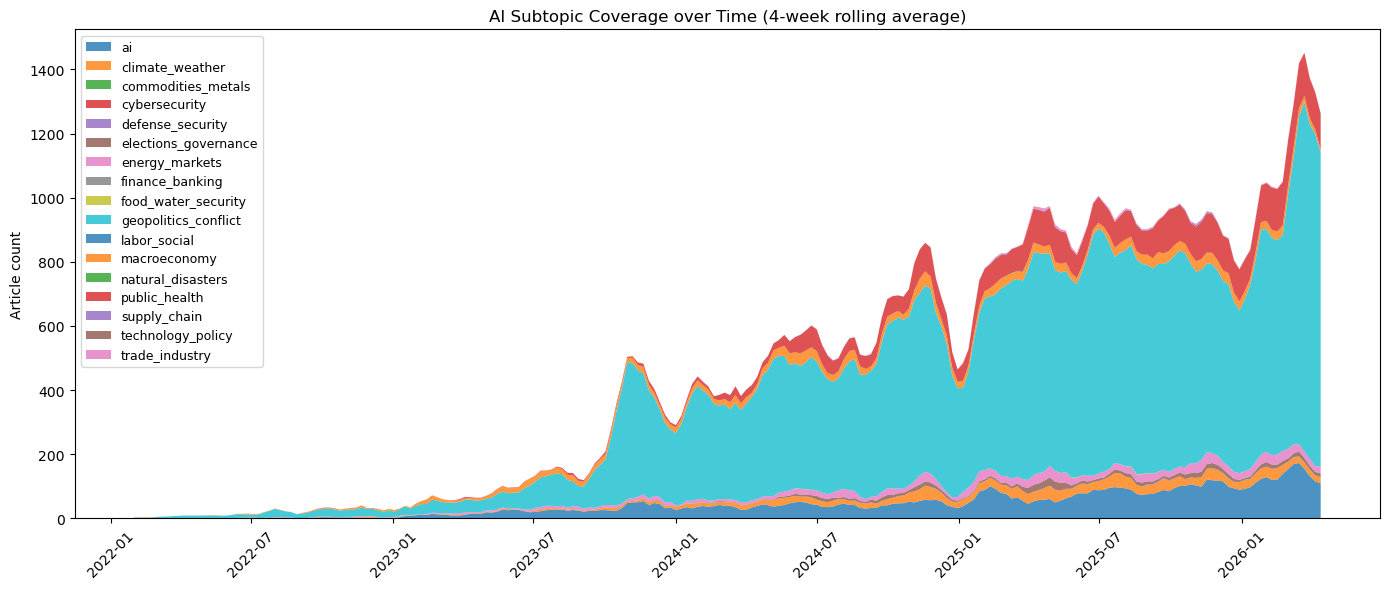

In [30]:
wide = ts.pivot_table(index='week', columns='subtopic', values='article_count', fill_value=0)
wide_smooth = wide.rolling(4).mean().dropna()

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(wide_smooth.index, wide_smooth.T, labels=wide_smooth.columns, alpha=0.8)
ax.legend(loc='upper left', fontsize=9)
ax.set_title('AI Subtopic Coverage over Time (4-week rolling average)')
ax.set_ylabel('Article count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/stacked_area.png', dpi=150)
plt.show()

## 4. Sentiment Heatmap — per Subtopic per Month

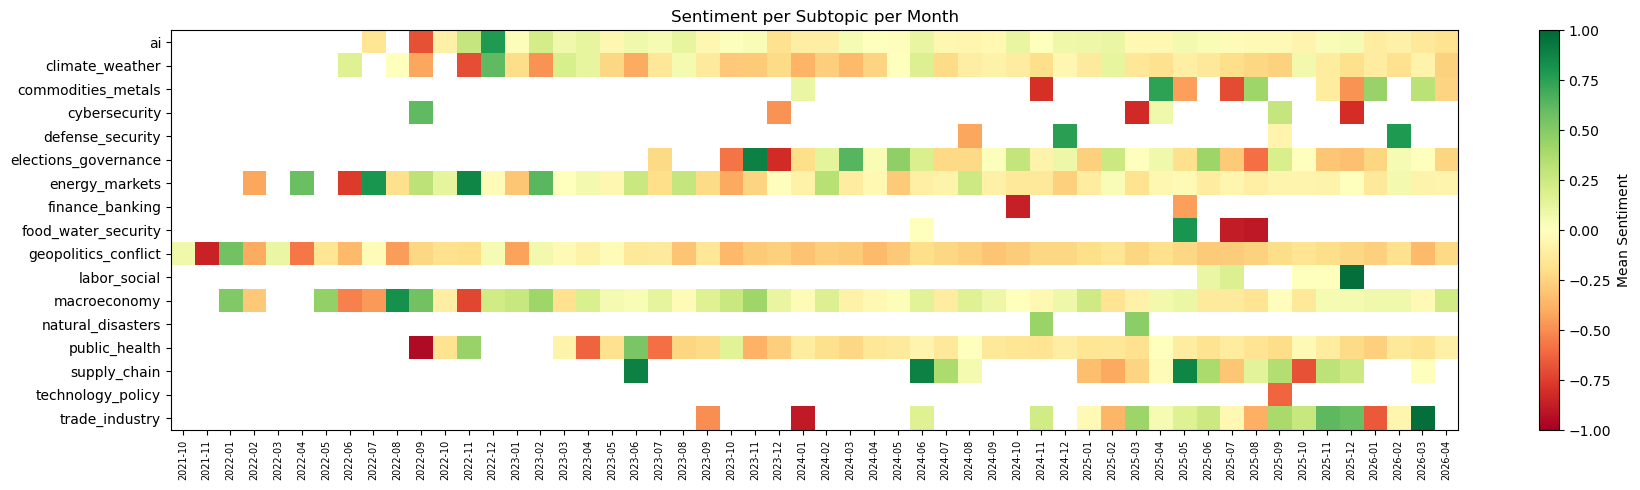

In [31]:
ts['month'] = ts['week'].dt.to_period('M').astype(str)
heatmap_data = ts.pivot_table(index='subtopic', columns='month', values='sentiment_mean')

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=90, fontsize=7)
ax.set_title('Sentiment per Subtopic per Month')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Mean Sentiment')
plt.tight_layout()
plt.savefig('data/sentiment_heatmap.png', dpi=150)
plt.show()

## 5. Cross-correlation — Does one subtopic lead another?

Cross-correlation: "geopolitics_conflict" → "defense_security"


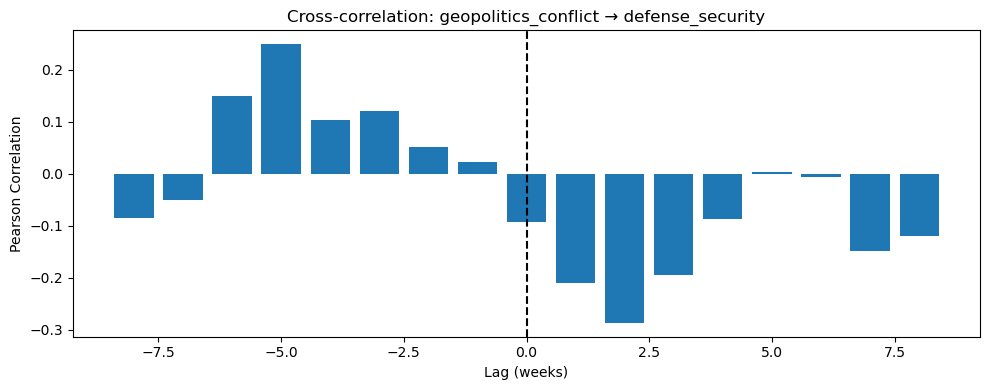

Peak correlation at lag=-5 weeks (positive = A leads B)


In [32]:
# Cross-correlation: does one subtopic lead another?
# After running NB 02, set TOPIC_A and TOPIC_B to two of your discovered subtopics.
# Default picks the two largest topics automatically as a starting point.
topic_sizes = ts.groupby('subtopic')['article_count'].sum().sort_values(ascending=False)
TOPIC_A = topic_sizes.index[0] if len(topic_sizes) > 0 else subtopics[0]
TOPIC_B = topic_sizes.index[11] if len(topic_sizes) > 1 else subtopics[1]

# Override manually if desired, e.g.:
# TOPIC_A = 'AI Safety & Alignment'
# TOPIC_B = 'AI Regulation & Policy'

print(f'Cross-correlation: "{TOPIC_A}" → "{TOPIC_B}"')

a = ts[ts['subtopic'] == TOPIC_A].set_index('week')['article_count'].resample('W').sum().fillna(0)
b = ts[ts['subtopic'] == TOPIC_B].set_index('week')['article_count'].resample('W').sum().fillna(0)

# Align on same index
a, b = a.align(b, join='inner')

lags = range(-8, 9)  # -8 to +8 weeks
correlations = [a.corr(b.shift(lag)) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, correlations)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Pearson Correlation')
ax.set_title(f'Cross-correlation: {TOPIC_A} → {TOPIC_B}')
plt.tight_layout()
plt.savefig('data/cross_correlation.png', dpi=150)
plt.show()

best_lag = list(lags)[correlations.index(max(correlations))]
print(f'Peak correlation at lag={best_lag} weeks (positive = A leads B)')